In [2]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

In [11]:
data = pd.read_csv('train.csv')

In [12]:
data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
x = data.iloc[:,1:]
y = data.iloc[:,0]

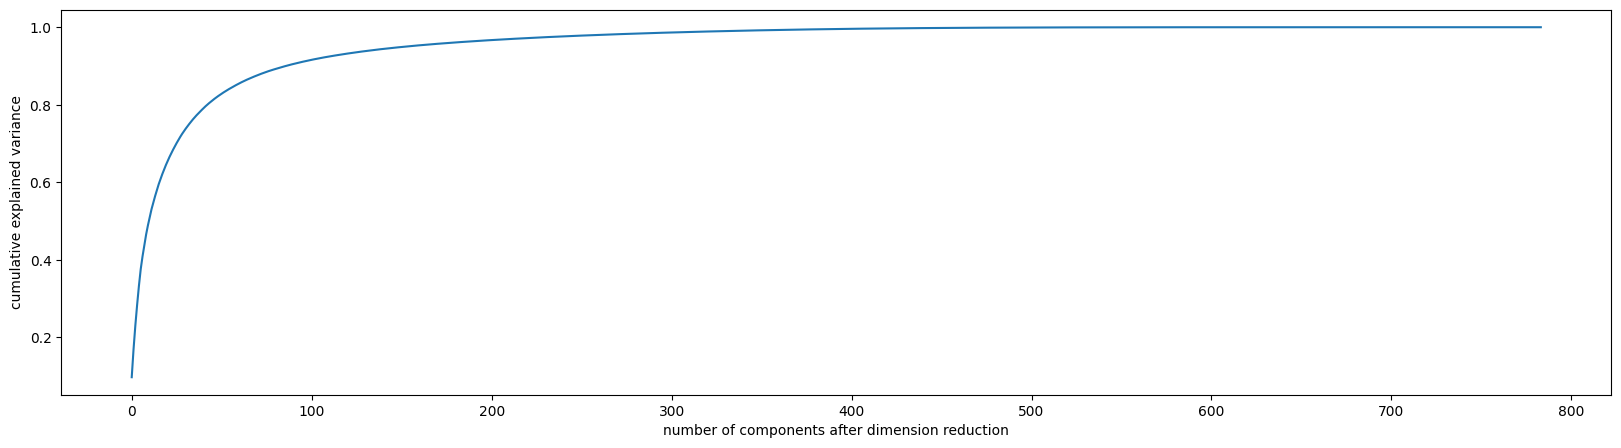

In [19]:
import matplotlib.pyplot as plt
pca_line = PCA().fit(x)
plt.figure(figsize=[20,5])
plt.plot(np.cumsum(pca_line.explained_variance_ratio_))
plt.xlabel('number of components after dimension reduction')
plt.ylabel('cumulative explained variance')
plt.show()


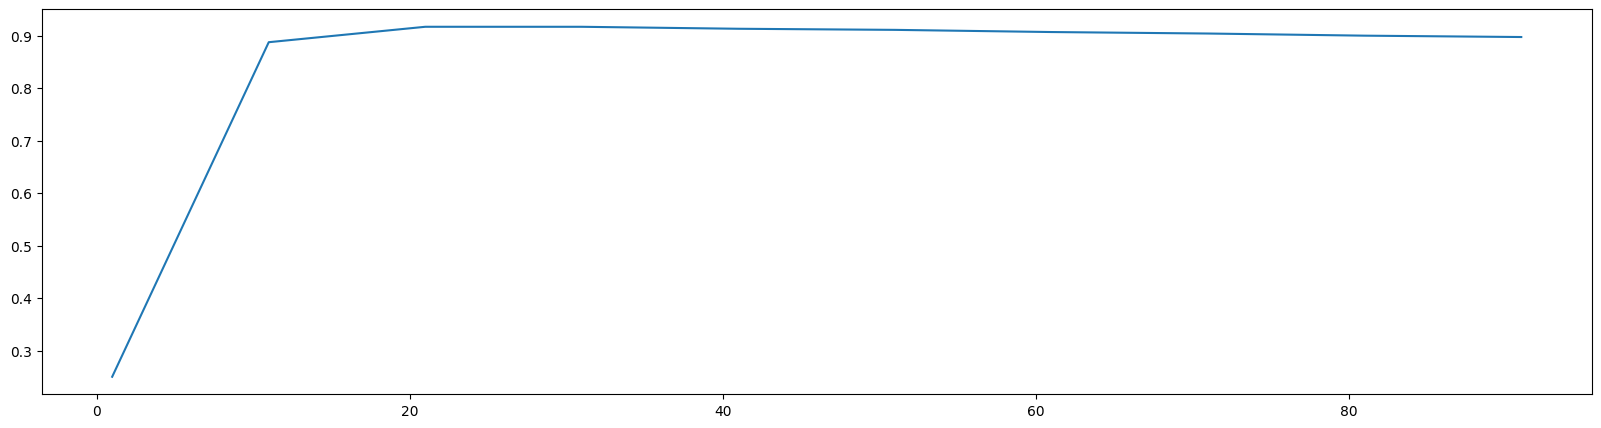

In [23]:
score = []
for i in range(1,101,10):
    x_dr = PCA(i).fit_transform(x)
    once = cross_val_score(RFC(n_estimators=10,random_state=1)
                           ,x_dr,y,cv=5).mean()
    score.append(once)
plt.figure(figsize=[20,5])
plt.plot(range(1,101,10),score)
plt.show()

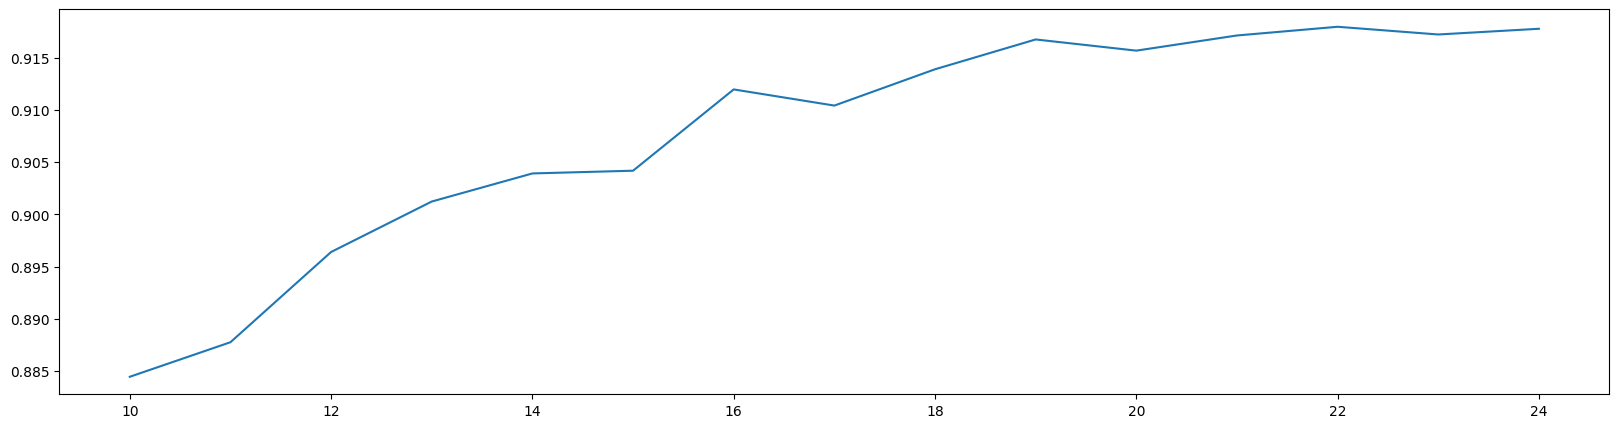

In [24]:
score = []
for i in range(10,25,1):
    x_dr = PCA(i).fit_transform(x)
    once = cross_val_score(RFC(n_estimators=10,random_state=1)
                           ,x_dr,y,cv=5).mean()
    score.append(once)
plt.figure(figsize=[20,5])
plt.plot(range(10,25,1),score)
plt.show()

In [25]:
x_dr = PCA(23).fit_transform(x)
cross_val_score(RFC(n_estimators = 10, random_state =1 ),x_dr,y,cv=5).mean()

np.float64(0.9172380952380953)

In [26]:

x_dr.shape

(42000, 23)

In [27]:
cross_val_score(RFC(n_estimators = 100, random_state =1 ),x_dr,y,cv=5).mean()

np.float64(0.9462857142857143)

In [28]:
from sklearn.neighbors import KNeighborsClassifier as KNN


In [29]:
cross_val_score(KNN(),x_dr,y,cv=5).mean()

np.float64(0.9699285714285715)

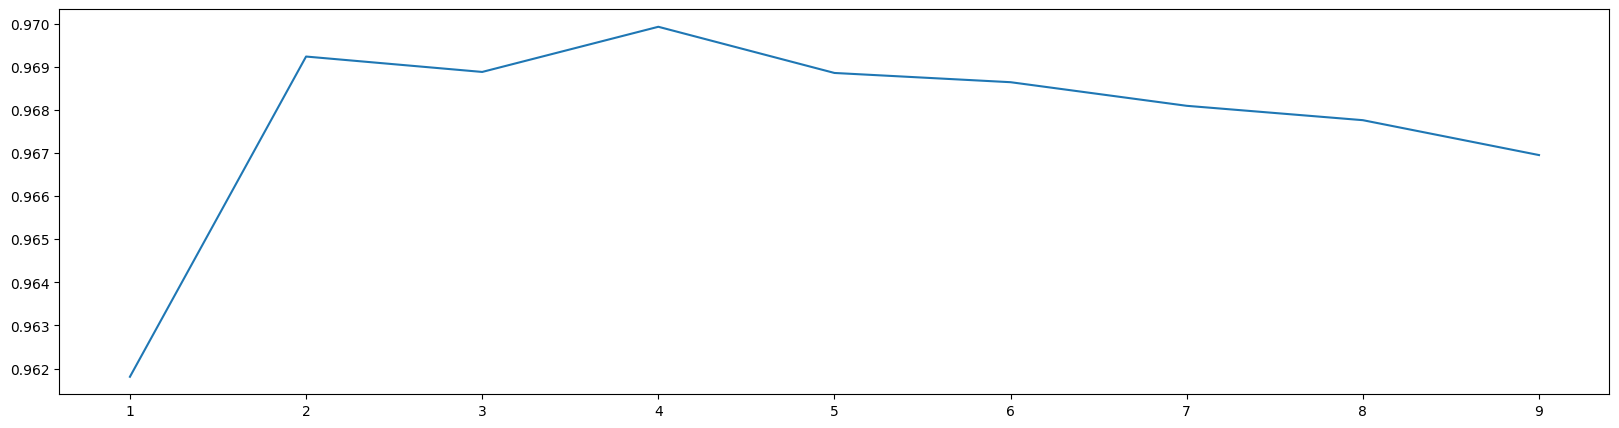

In [31]:
score = []
for i in range(1,10,1):
    x_dr = PCA(23).fit_transform(x)
    once = cross_val_score(KNN(1+i)
                           ,x_dr,y,cv=5).mean()
    score.append(once)
plt.figure(figsize=[20,5])
plt.plot(range(1,10,1),score)
plt.show()

In [32]:
cross_val_score(KNN(4),x_dr,y,cv=5).mean()

np.float64(0.9688809523809525)